Saved plot to /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_d/plot_d_files/RNA_L18_meanG_plot.png


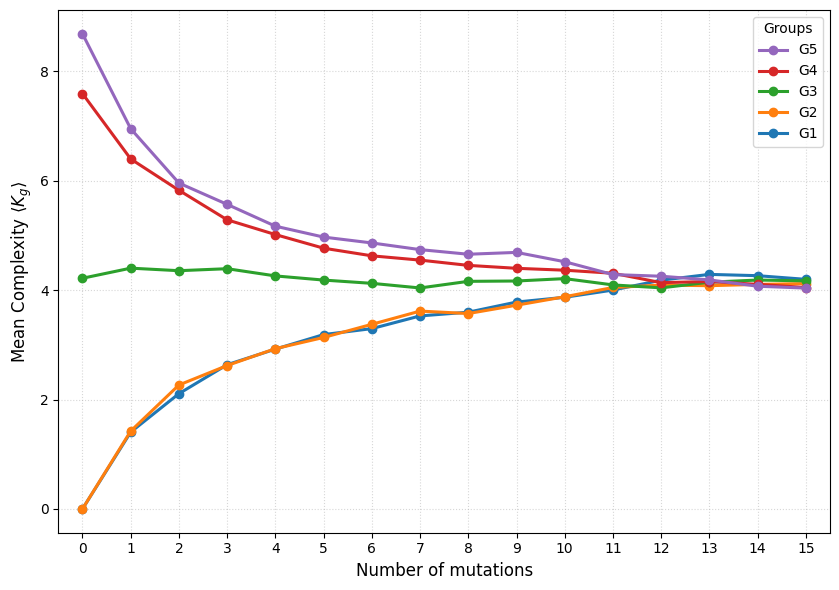

In [2]:
# Plot RNA L=18 MeanG1..MeanG5 (Notebook-friendly)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- configure ----------
csv_path = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
    "mut_project_updates/figures/RNA/L_18/plot_d/plot_d_files/RNA_L18_k_scaled_1_for_plot_D.csv"
)
output_dir = csv_path.parent
out_png = output_dir / "RNA_L18_meanG_plot.png"

marker = "o"
linewidth = 2.2
marker_size = 6
# --------------------------------

# Load CSV
df = pd.read_csv(csv_path)
if df.empty:
    raise RuntimeError(f"No data found in {csv_path}")

# Attempt to detect x-values column
first_col = df.columns[0]
first_col_lower = first_col.lower()
if any(k in first_col_lower for k in ("mut", "number", "n", "k")):
    x_vals = df.iloc[:, 0].to_numpy()
    data_df = df.iloc[:, 1:].copy()
else:
    # no explicit x column — use integer positions and keep whole dataframe as data
    x_vals = np.arange(len(df))
    data_df = df.copy()

# Find MeanG* columns (case-insensitive)
meang_cols = [c for c in data_df.columns if str(c).lower().startswith("meang")]
if not meang_cols:
    # fallback: try columns named G1..G5 or MeanG1 style variations
    meang_cols = [c for c in data_df.columns if any(s in str(c).lower() for s in ("g1","g2","g3","g4","g5"))]

if not meang_cols:
    raise RuntimeError("No MeanG* columns found in CSV. Columns found: " + ", ".join(map(str, data_df.columns)))

# Prepare arrays (convert to numeric, preserve NaNs)
series_vals = []
labels = []
for c in meang_cols:
    vals = pd.to_numeric(data_df[c], errors="coerce").to_numpy()
    series_vals.append(vals)
    labels.append(str(c))

series_vals = np.array(series_vals)  # shape (n_series, n_points)

# x tick labels — use integer positions relative to x_vals if those are numeric and consecutive
if np.issubdtype(x_vals.dtype, np.number):
    x_positions = np.arange(len(x_vals))
    x_tick_labels = [str(int(x)) if float(x).is_integer() else f"{x:.3g}" for x in x_vals]
else:
    # non-numeric x (unlikely) — use index positions and textual ticks
    x_positions = np.arange(len(x_vals))
    x_tick_labels = [str(x) for x in x_vals]

# Plot (matching style you liked)
plt.figure(figsize=(8.5, 6))
for i, vals in enumerate(series_vals):
    label = f"G{i+1}"  # e.g. 'MeanG1'
    plt.plot(x_positions, vals, marker=marker, linewidth=linewidth,
             markersize=marker_size, label=label)

# cosmetics
plt.xlabel("Number of mutations", fontsize=12)
plt.ylabel(r"Mean Complexity $\langle K_g \rangle$", fontsize=12)
plt.xticks(x_positions, x_tick_labels)
plt.grid(True, linestyle=":", alpha=0.5)

# reverse legend order (so G5 -> G1) and set title "Groups"
handles, legend_labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], legend_labels[::-1], title="Groups", loc="upper right")

# add 0.5 tick spacing margin on both sides (based on current tick spacing)
if len(x_positions) > 1:
    spacing = x_positions[1] - x_positions[0]
else:
    spacing = 1.0
plt.xlim(x_positions[0] - 0.5 * spacing, x_positions[-1] + 0.5 * spacing)

plt.tight_layout()
plt.savefig(out_png, dpi=150)
print(f"Saved plot to {out_png}")
plt.show()